# 3 MACHINE  LEARNING FOR CLASSIFICATION   机器学习用于分类

### 客户流失项目
预测哪些客户即将流失，并给每位客户分配1个介于0到1之间的数值，以表示该客户的留存的可能性。
如果预测某些客户可能流失，我们会向他发送一些促销邮件，提供商品和服务的折扣。
同时我们不想给不会流失的客户提供折扣，因为那样会导致亏损。所以要做到预测的精准，才能保证折扣券发送的精准。
我们使用机器学习的二元分类方法来解决这个问题。

# 3.1  Churn prediction project   流失预测项目 & 下载数据

In [2]:
#https://www.kaggle.com/blastchar/telco-customer-churn
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_69863/2086256129.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|█████████████████████████████████████| 955k/955k [00:01<00:00, 689kB/s]

First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

# 3.2  数据准备  Data  Preparation

In [16]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv') 
df 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [17]:
df.dtypes.count()

np.int64(21)

In [18]:
df.head().T  # 哈哈哈，可以这样转置一下，让列成了行

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [19]:
df.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [20]:
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [21]:
df.dtypes[df.dtypes == 'str'].index  # 这里显示的结果，是个元组，需要把他转换成列表

Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod', 'totalcharges',
       'churn'],
      dtype='str')

In [22]:
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)  # 找到属性是‘str’的所有字段
categorical_columns

['customerid',
 'gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'totalcharges',
 'churn']

In [23]:
for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(' ','_')

In [24]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


In [25]:
df.dtypes   # 这里要逐一检查每个字段的属性，看看是否合理，是否需要做处理
#  seniorcitizen  这是个内容就是0 和1，totalcharges  这个字段是字符串类型，应该是数值类型才对

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [27]:
# 处理字段类型
tc = pd.to_numeric(df.totalcharges,errors='coerce')  
# 注意，除了把字段修改为数值类型，将无法转换的值强制转换为 NaN（缺失值）

In [28]:
type(tc)

pandas.Series

In [29]:
tc.isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: totalcharges, Length: 7043, dtype: bool

In [30]:
df[tc.isnull()][['customerid','totalcharges'] ]   #  原始 DataFrame 中所有 TotalCharges 转换后为缺失值（NaN）的行,显示出来

,customerid,totalcharges
488,4472-lvygi,_
753,3115-czmzd,_
936,5709-lvoeq,_
1082,4367-nuyao,_
1340,1371-dwpaz,_
3331,7644-omvmy,_
3826,3213-vvolg,_
4380,2520-sgtta,_
5218,2923-arzlg,_
6670,4075-wkniu,_


In [31]:
df.totalcharges = pd.to_numeric(df.totalcharges,errors='coerce') # 处理这11行数值，先找出来，同时把列属性修改为数值类型

In [32]:
df.totalcharges.isnull().sum()  # 查看totalcharges的空值统计情况

np.int64(11)

In [33]:
# 然后空值填充0
df.totalcharges = df.totalcharges.fillna(0)

In [34]:
df.loc[df.index[[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]], 
       ['customerid', 'totalcharges']]  #查看填充后的效果。其实填充0肯定不是最合适的，先这样吧，alexey说这通常是可以的，然不是最佳

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


In [35]:
# 下面看流失率这个字段的情况
df.churn.head()    # 这里有问题，字段类型是str，内容是字符 ，yes  no  需要转换为1  0 

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [36]:
df.churn = (df.churn == 'yes').astype(int)   

In [37]:
# 检查数据集中的所有空值情况
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [38]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

# 3.3 配置验证框架 Setting up the validation framework  
Perform the train/validation/test split with Scikit-Learn  使用 Scikit-Learn 进行训练/验证/测试划分
使用cycler去配置搭建

In [39]:
from sklearn.model_selection import train_test_split  #导入库  

In [40]:
df_full_train,df_test = train_test_split(df, test_size=0.2, random_state=1)  # 设置 random_state=1，保证可复现的随机数

In [41]:
len(df_full_train),len(df_test)

(5634, 1409)

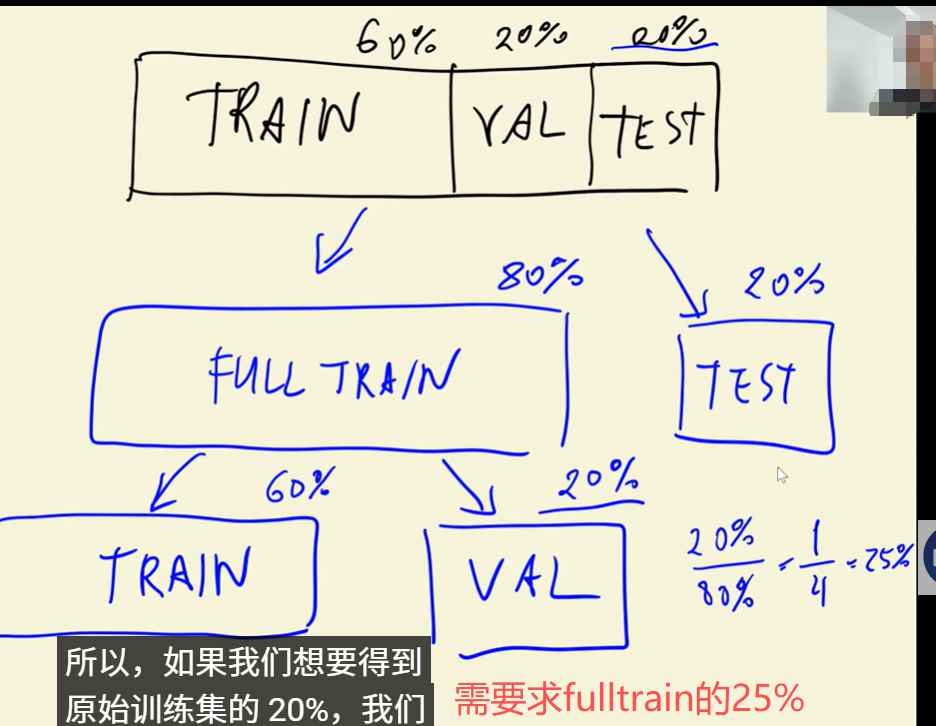

In [42]:
df_train,df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)  # 设置 random_state=1，保证可复现的随机数

In [43]:
len(df_full_train),len(df_test),len(df_train),len(df_val)

(5634, 1409, 4225, 1409)

In [44]:
df_train = df_train.reset_index(drop=True)   #将上面划分数据打乱的索引，重建索引，并删除旧索引
df_val = df_val.reset_index(drop=True) 
df_test = df_test.reset_index(drop=True) 

In [45]:
# 求解三部分数据集的y值，numpy类型
y_train = df_train.churn.values 
y_val = df_val.churn.values 
y_test = df_test.churn.values 

In [46]:
# 删除三部分数据集的y值,防止y值在数据集被用作训练验证和测试时，被意外使用
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [47]:
df_full_train
# 注意，这个数据集即没有索引重建，也没有删除y值，我们将在下一节中，看一这个目标变量（流失） Look at the target variable (churn) 

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
1814,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
5946,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
3881,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
2389,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
3676,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,0781-lkxbr,male,1,no,no,9,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,100.50,918.60,1
5192,3507-gasnp,male,0,no,yes,60,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.95,1189.90,0
3980,8868-wozgu,male,0,no,no,28,yes,yes,fiber_optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic_check,105.70,2979.50,1
235,1251-krreg,male,0,no,no,2,yes,yes,dsl,no,...,no,no,no,no,month-to-month,yes,mailed_check,54.40,114.10,1


# 3.4 探索性数据分析 EDA 
检查缺失值                  Check missing values 

查看目标变量（流失）       Look at the target variable (churn) 

查看数值型和分类型变量     Look at numerical and categorical variables

In [48]:
df_full_train = df_full_train.reset_index(drop=True) # 重置索引

In [49]:
df_full_train.T

,0,1,2,3,4,5,6,7,8,9,...,5624,5625,5626,5627,5628,5629,5630,5631,5632,5633
customerid,5442-pptjy,6261-rcvns,2176-osjuv,6161-erdgd,2364-ufrom,4765-oxppd,0742-lafqk,5213-twwju,9957-yodkz,1732-vhubq,...,5345-bmkwb,1131-qqzeb,3262-eidhv,7446-sfaoa,2250-ivbwa,0781-lkxbr,3507-gasnp,8868-wozgu,1251-krreg,5840-nvdcg
gender,male,female,male,male,male,female,male,male,male,female,...,male,male,female,female,male,male,male,male,male,female
seniorcitizen,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,1,0,0,0,0
partner,yes,no,yes,yes,no,yes,yes,no,yes,yes,...,yes,yes,yes,yes,yes,no,no,no,no,yes
dependents,yes,no,no,yes,no,yes,no,no,no,yes,...,no,no,yes,no,yes,no,yes,no,no,yes
tenure,12,42,71,71,30,9,72,28,6,47,...,8,71,72,37,64,9,60,28,2,16
phoneservice,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,...,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
multiplelines,no,no,yes,yes,no,no,yes,no,yes,no,...,no,yes,yes,no,no,yes,no,yes,yes,no
internetservice,no,dsl,dsl,dsl,dsl,dsl,fiber_optic,fiber_optic,fiber_optic,fiber_optic,...,no,no,dsl,no,fiber_optic,fiber_optic,no,fiber_optic,dsl,dsl
onlinesecurity,no_internet_service,yes,yes,yes,yes,yes,yes,no,no,no,...,no_internet_service,no_internet_service,yes,no_internet_service,yes,no,no_internet_service,no,no,yes


In [50]:
# 在这个数据里面，我们做一些探索
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [51]:
df_full_train.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [52]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [53]:
# 全局流失率
global_churn_rate = df_full_train.churn.mean()   # 计算流失率的平均值，因为计算平均值也可以得到流失率.其实就是计算1在整个数组中的占比
global_churn_rate

np.float64(0.26996805111821087)

In [54]:
round(global_churn_rate,2)  # 用户流失率是27%

np.float64(0.27)

In [55]:
# 分类型变量
df_full_train.dtypes   # 查看数据集中，列的类型是str的

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [56]:
df.dtypes.index

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [57]:
# 手动筛选分类，原则：业务上取值有限、离散、无序，且不能当数字做运算的列，就是分类变量。
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents','phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling','paymentmethod']

In [58]:
df_full_train[categorical].nunique()  # 取分类列中的唯一值的数量，可以看到大部分是2元或者3元，还有支付方式4元

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [59]:
# 数值型变量

# 3.5  特征重要性：流失率和风险比率  
# Feature importance: Churn rate and risk ratio
- 特征重要性分析（探索性数据分析的一部分）——识别哪些特征会影响我们的目标变量    Feature importance analysis (part of EDA) - identifying which features affect our target variable
-  流失率和风险比率  Churn rate· Risk ratio
-   互助性息  mutual information - Ater

### Churn rate

In [60]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean() # 查看女性用户的流失率
churn_female

np.float64(0.27682403433476394)

In [61]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean() # 查看男性用户的流失率
churn_male

np.float64(0.2632135306553911)

In [62]:
churn_global =  df_full_train.churn.mean()  # 整体流失率
churn_global

np.float64(0.26996805111821087)

In [63]:
df_full_train.partner.value_counts()   # 有伴侣用户和无伴侣用户的统计

partner
no     2932
yes    2702
Name: count, dtype: int64

In [64]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()  # 有伴侣的用户流失率，只有20%
churn_partner

np.float64(0.20503330866025166)

In [65]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()  # 无伴侣的用户流失率，只有33%
churn_no_partner

np.float64(0.3298090040927694)

In [66]:
churn_global - churn_partner

np.float64(0.06493474245795922)

In [67]:
churn_global - churn_no_partner

np.float64(-0.05984095297455855)

### 综上：
- 用户整体流失率，与男性流失率和女性流失相当，几乎没有差异；
- 用户整体流失率，显著高于 有伴侣用户的流失率，显著低于 无伴侣用户的流失率
### 结果判断：
**用户是否有伴侣，这个特征，比性别特征，对预测流失率，更为重要，**

### Risk ratio

In [68]:
churn_no_partner / churn_global

np.float64(1.2216593879412643)

In [69]:
 churn_partner / churn_global

np.float64(0.7594724924338315)

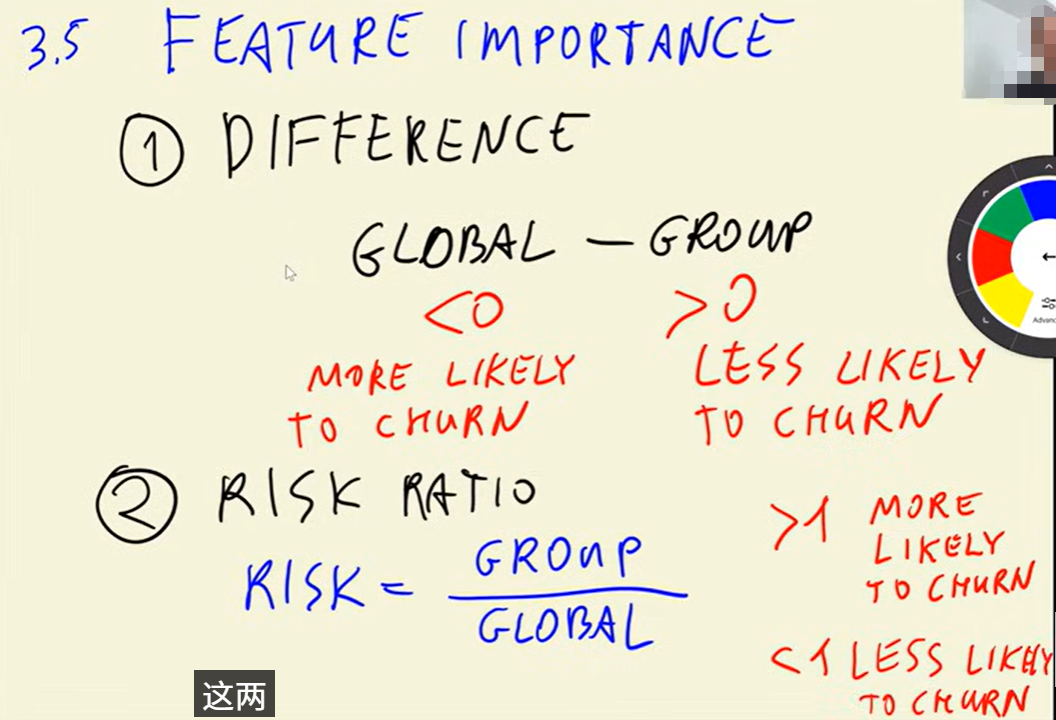

SELECT
gender,
AVG(churn),
AVG(churn) - churn_global AS diff,
AVG(churn) / churn_global AS risk
FROM
data
GROUP BY
gender;

In [70]:
# 将上面的sql，写成pandas的形式。
df_group = df_full_train.groupby('gender').churn.agg(['mean','count'])
df_group['diff'] =  churn_global - df_group['mean'] 
df_group['risk'] = df_group['mean'] / churn_global
df_group

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,-0.006856,1.025396
male,0.263214,2838,0.006755,0.974980


In [71]:
# 找出‘分类变量’中的所有特征值的流失率，与整体流失率的‘不同’和‘风险率’
from IPython.display import display  # 用于在交互环境中渲染输出图片、表格、音频、视频、HTML、DataFrame 等丰富内容

In [72]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean','count'])
    df_group['diff'] = churn_global - df_group['mean']
    df_group['risk'] = df_group['mean'] / churn_global
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,-0.006856,1.025396
male,0.263214,2838,0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,0.027698,0.897403
1,0.413377,912,-0.143409,1.531208




partner


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,-0.059841,1.221659
yes,0.205033,2702,0.064935,0.759472




dependents


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,-0.043792,1.162212
yes,0.165666,1666,0.104302,0.613651




phoneservice


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,0.028652,0.893870
yes,0.273049,5087,-0.003081,1.011412




multiplelines


,mean,count,diff,risk
multiplelines,,,,
no,0.257407,2700,0.012561,0.953474
no_phone_service,0.241316,547,0.028652,0.893870
yes,0.290742,2387,-0.020773,1.076948




internetservice


,mean,count,diff,risk
internetservice,,,,
dsl,0.192347,1934,0.077621,0.712482
fiber_optic,0.425171,2479,-0.155203,1.574895
no,0.077805,1221,0.192163,0.288201




onlinesecurity


,mean,count,diff,risk
onlinesecurity,,,,
no,0.420921,2801,-0.150953,1.559152
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.153226,1612,0.116742,0.567570




onlinebackup


,mean,count,diff,risk
onlinebackup,,,,
no,0.404323,2498,-0.134355,1.497672
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.217232,1915,0.052736,0.804660




deviceprotection


,mean,count,diff,risk
deviceprotection,,,,
no,0.395875,2473,-0.125907,1.466379
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.230412,1940,0.039556,0.853480




techsupport


,mean,count,diff,risk
techsupport,,,,
no,0.418914,2781,-0.148946,1.551717
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.159926,1632,0.110042,0.592390




streamingtv


,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,-0.072864,1.269897
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.302723,2167,-0.032755,1.121328




streamingmovies


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,-0.068938,1.255358
no_internet_service,0.077805,1221,0.192163,0.288201
yes,0.307273,2200,-0.037305,1.138182




contract


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,-0.161733,1.599082
one_year,0.120573,1186,0.149395,0.446621
two_year,0.028274,1344,0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,0.097897,0.637375
yes,0.338151,3321,-0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,0.101797,0.622928
credit_card_(automatic),0.164339,1217,0.105630,0.608733
electronic_check,0.455890,1893,-0.185922,1.688682
mailed_check,0.193870,1305,0.076098,0.718121


# 3.6  特征重要性：互助信息    Feature importance: Mutual information
互助信息——来自信息论的概念，它告诉我们如果已知一个变量的取值，我们能对另一个变量了解多少。
Mutual information - concept from information theory, it tells us how much we can learn about one variable if we know the value of another
Mutual information 它是一种***衡量分类变量重要性的指标***。

### 上面3.5最后的for循环代码中，我们找出了‘分类变量’中的所有特征值的流失率，与整体流失率的‘不同’和‘风险率’
但我们没办法确认，这些分类变量中，哪些更重要，或者哪个变量比其他变量更不重要。
Mutual information 是信息论中的1个概念，它可以告诉我们，每个变量的重要性。
Mutual information 值越高，我们通过观察另1个变量的值，就能了解越多关于用户流失的信息。

In [73]:
from sklearn.metrics import mutual_info_score

In [74]:
# 它告诉我们，通过观察合同变量的值，我们能了解到多少关于客户流失的信息
mutual_info_score(df_full_train.contract,df_full_train.churn)

0.0983203874041556

In [75]:
mutual_info_score(df_full_train.gender,df_full_train.churn)

0.0001174846211139946

#### 以上两条内容，我们可以获知，用户签订合同的类型和用户的性别，前者获得信息比后者的信息更重要。
#### 下面我们把所有的分类都求出对应的mutual值

In [76]:
def  mutual_info_churn_score(series):
    return mutual_info_score(series,df_full_train.churn)

In [77]:
mi = df_full_train[categorical].apply(mutual_info_churn_score) 
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

# 3.7  特征重要性：相互关系，关联，相关量      Feature importance: Correlation
数值列又是如何影响流失率的呢？     How about numerical columns?
相关系数     Correlation coefficient ：一个数值或函数，用于表示两组数据或两个随机变量之间的相关程度，其值等于它们的协方差除以它们标准差的乘积。

### 3.6 是衡量分类特征的重要性的指标，这一节讨论数值类型的变量。
### pearson 相关性系数：是衡量两个变量之间依赖关系的指标。
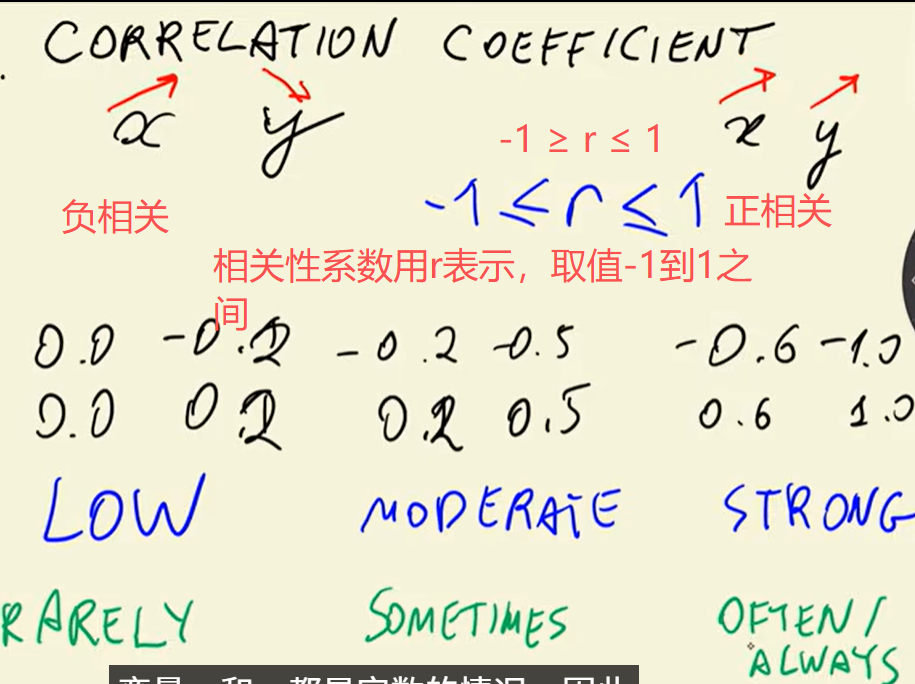

#### 在我们的案例中，数据集的y值，是1个二元变量，0表示用户未流失，1表示用户流失了
#### 假设X是‘tenure’，即用户在我们这里停留的月数；y 是churn。
####  tenure，它是1个变量，假设它的取值范围是：0  到 72  (df_full_train.tenure.min() 和max()去查看）
上述情况下，
- x 和 y 之间如果存在***正相关***，表示：当x增加时，客户留存时间越长，客户流失率就越高。
- x 和 y 之间，如果存在***负相关***，则表示：当x增加时，客户留存时间越长，客户流失率就越低。
- x 和 y 之间，如果存在***零相关***，则表示：x的增加或者减少，对客户的流失率没有影响，不相关。
#### 下面我们就找一找，数据集中，数值变量与y值‘流失率churn’之间的相关性。

In [78]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [79]:
numerical = ['tenure','monthlycharges','totalcharges']

In [80]:
cor = df_full_train[numerical].corrwith(df_full_train.churn) # 求出相关性
cor.sort_values()

tenure           -0.351885
totalcharges     -0.196353
monthlycharges    0.196805
dtype: float64

#### 相关性结果：
- tenure              当用户的留存时长增加时，用户的流失率会持续下降； ***负相关**
- totalcharges        当用户的总费用增长时，用户的流失率会持续下降；***负相关***
- monthlycharges      当用户的月度费用增长时，用户的流失率会持续上升；***正相关***
#### 如果把结果的‘负号’去掉
表示： tenure  对于用户的流失率是最重要的指标，另外两个重要性差不多

In [81]:
# 我们来验证一下相关性的结果,查看用户留存时长，与用户流失率的关系
df_full_train[df_full_train.tenure <=2].churn.mean()

np.float64(0.5953420669577875)

In [82]:
df_full_train[(df_full_train.tenure >2) & (df_full_train.tenure <=12)].churn.mean()

np.float64(0.3994413407821229)

In [83]:
df_full_train[(df_full_train.tenure >12) & (df_full_train.tenure <=72)].churn.mean()

np.float64(0.17634908339788277)

#### 以上3行代码，表示了：随着用户留存时长的增加，，用户的流失率是显著降低的
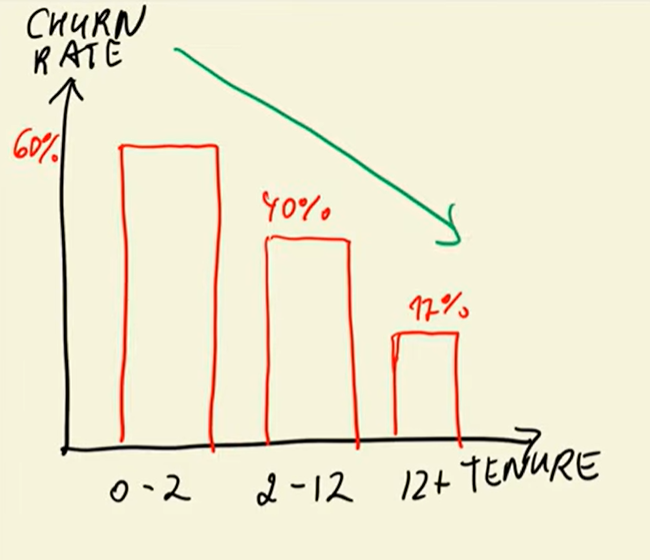

#### 再看一下其他的数值变量的情况

In [84]:
monthlycharges_min = df_full_train.monthlycharges.min()
monthlycharges_min

np.float64(18.25)

In [85]:
monthlycharges_max = df_full_train.monthlycharges.max()
monthlycharges_max

np.float64(118.65)

In [86]:
df_full_train[df_full_train.monthlycharges <=20].churn.mean()

np.float64(0.08795411089866156)

In [87]:
df_full_train[(df_full_train.monthlycharges >=20) & (df_full_train.monthlycharges <=50)].churn.mean()

np.float64(0.18074074074074073)

In [88]:
df_full_train[(df_full_train.monthlycharges >=50)].churn.mean()

np.float64(0.3248223216635957)

### 以上对月度费用的数值变量与用户流失率的关系，表明：***月度费用越高***，***用户流失率越高***
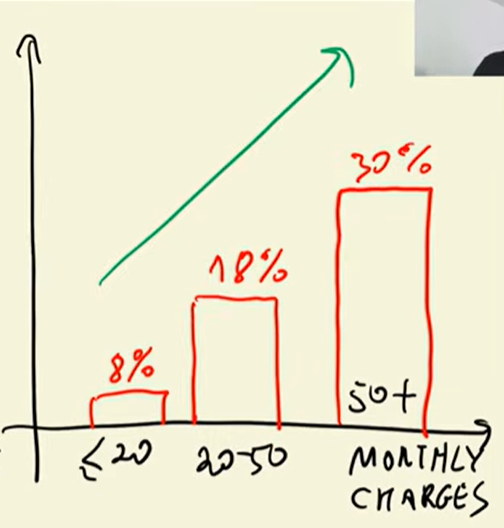

# 3.8  独热编码   One-hot encoding
- 使用 Scikit-Learn 对分类特征进行编码     · Use Scikit-Learn to encode categorical features

#### 这节的内容，主要是讲，如何对***分类特征进行编码***
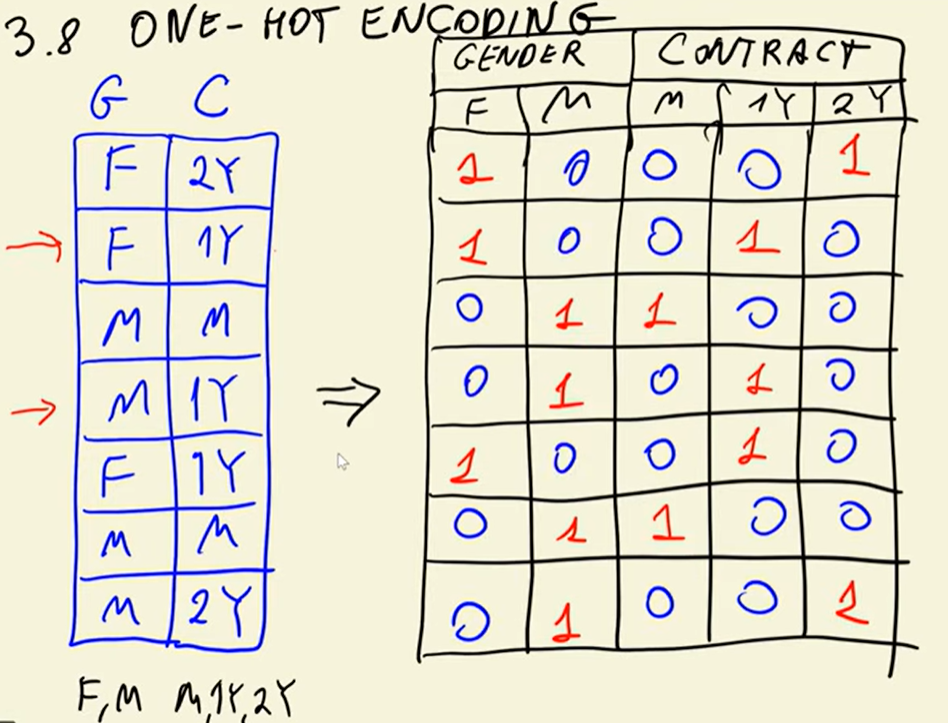

In [89]:
from sklearn.feature_extraction  import DictVectorizer   #导入字典向量 库

In [90]:
df_train[['gender','contract']].iloc[:100]   

,gender,contract
0,female,two_year
1,male,month-to-month
2,female,month-to-month
3,female,month-to-month
4,female,two_year
...,...,...
95,male,one_year
96,female,month-to-month
97,male,month-to-month
98,male,one_year


In [91]:
# 把上面的结果转换成字典类型，发现是嵌套字典类型，
# 它的优点是按列访问高效（比如要获取所有性别，一次就能拿到），但缺点是按行访问不够直观。
df_train[['gender','contract']].iloc[:100].to_dict()

{'gender': {0: 'female',
  1: 'male',
  2: 'female',
  3: 'female',
  4: 'female',
  5: 'male',
  6: 'male',
  7: 'female',
  8: 'female',
  9: 'female',
  10: 'female',
  11: 'male',
  12: 'female',
  13: 'female',
  14: 'female',
  15: 'male',
  16: 'female',
  17: 'female',
  18: 'male',
  19: 'male',
  20: 'male',
  21: 'female',
  22: 'female',
  23: 'female',
  24: 'male',
  25: 'male',
  26: 'female',
  27: 'female',
  28: 'female',
  29: 'female',
  30: 'male',
  31: 'male',
  32: 'female',
  33: 'female',
  34: 'male',
  35: 'female',
  36: 'female',
  37: 'male',
  38: 'male',
  39: 'female',
  40: 'female',
  41: 'male',
  42: 'female',
  43: 'male',
  44: 'male',
  45: 'female',
  46: 'male',
  47: 'female',
  48: 'male',
  49: 'female',
  50: 'male',
  51: 'male',
  52: 'female',
  53: 'male',
  54: 'female',
  55: 'female',
  56: 'male',
  57: 'male',
  58: 'female',
  59: 'female',
  60: 'male',
  61: 'female',
  62: 'male',
  63: 'female',
  64: 'male',
  65: 'male',
  

In [92]:
# 把上面的结果转换成字典类型，这次是：列表嵌套字典（list of dicts），它是按照行组织的
dicts = df_train[['gender','contract']].iloc[:100].to_dict(orient='records')
dicts 

[{'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'one_year'},
 {'gender': 'male', 'contract': 'two_year'},
 {

In [93]:
dv = DictVectorizer(sparse=False)   # 初始化字典向量化器,不适用稀疏矩阵，如果这个参数不加，默认结果是稀疏矩阵类型的。
 #它可以把字典里的类别型字符串（比如 'female', 'male', 'two_year'），自动转换成机器能计算的数值向量（也就是数字）。
#这背后的技术叫做 One-Hot 编码（独热编码）。
dv.fit(dicts)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [94]:
dv.get_feature_names_out()  #这个输出，顺序对应到下面的每一列的字段

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male'], dtype=object)

In [95]:
dv.transform(dicts)   #返回1个普通的numpy数组，
# **注意**，我们这里演示的逻辑，使用的是分类变量，如果是‘数值变量’，则不会使用独热方式，而是保持原有数值，这里不再演示。

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0.

In [96]:
# 给训练数据集，取所有分类变量和数值变量中的所有数据行
train_dicts = df_train[categorical + numerical].to_dict(orient='records')

In [97]:
train_dicts[0] 

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [98]:
dv.fit(train_dicts)


,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [99]:
feature_names_out = dv.get_feature_names_out()  # 输出内容，可以留意到：数值类型，没有分类，只有1个字段
feature_names_out

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [100]:
len(feature_names_out)

45

In [101]:
X_train = dv.transform(train_dicts)

In [102]:
X_train.shape

(4225, 45)

In [103]:
# 合并一下数据处理的步骤,这个‘dv.fit_transform ’1个函数，就搞定了数据准备的核心工作，不需要分步操作
X_train1 = dv.fit_transform(train_dicts)

In [104]:
X_train1.shape

(4225, 45)

In [105]:
# 对验证数据集和测试数据集 做数据准备工作
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

In [106]:
# 注意，这里只做transform，不做fit，只有训练数据做fit就可以了。
X_val = dv.transform(val_dicts)

In [107]:
X_val.shape

(1409, 45)

# 3.9  逻辑回归    Logistic regression  
- 二进制分类                   Binary classification
- 线性回归 vs 逻辑回归         Linear vs logistic regression

#### 线性回归回答"是多少"，逻辑回归回答"是不是"。
#### 线性回归：预测房价
预测结果：8425.15 元/平米  ✅ 任意实数

#### 逻辑回归：预测是否流失
预测结果：0.87  →  表示有87%概率会流失  ✅ 0~1之间

逻辑回归本质：在线性回归基础上套了一个 Sigmoid 函数，把输出压缩到 (0,1) 区间

名字误会：虽然叫"回归"，但逻辑回归是分类算法（二分类常用）
#### 应用场景：
- **线性回归**：房价、温度、销量预测
- **逻辑回归**：垃圾邮件识别、客户流失预测、疾病诊断

In [108]:
def  sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [109]:
z = np.linspace(-5,5,51)  #在 -5 到 5 之间，等距离生成 51 个数字。

In [110]:
sigmoid(z)

array([0.00669285, 0.00816257, 0.0099518 , 0.01212843, 0.01477403,
       0.01798621, 0.02188127, 0.02659699, 0.03229546, 0.03916572,
       0.04742587, 0.05732418, 0.06913842, 0.0831727 , 0.09975049,
       0.11920292, 0.14185106, 0.16798161, 0.19781611, 0.23147522,
       0.26894142, 0.31002552, 0.35434369, 0.40131234, 0.450166  ,
       0.5       , 0.549834  , 0.59868766, 0.64565631, 0.68997448,
       0.73105858, 0.76852478, 0.80218389, 0.83201839, 0.85814894,
       0.88079708, 0.90024951, 0.9168273 , 0.93086158, 0.94267582,
       0.95257413, 0.96083428, 0.96770454, 0.97340301, 0.97811873,
       0.98201379, 0.98522597, 0.98787157, 0.9900482 , 0.99183743,
       0.99330715])

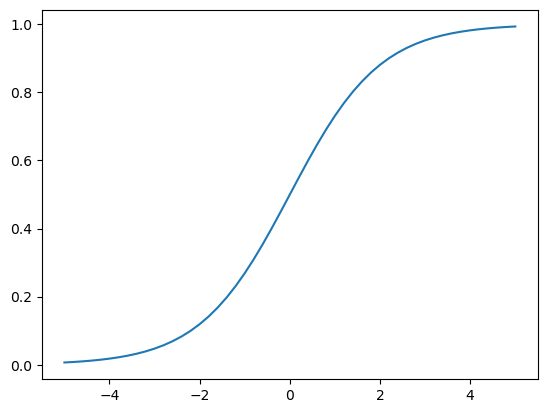

In [111]:
plt.plot(z,sigmoid(z))  

In [112]:
def logistic_regression(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]
    result = sigmoid(score)
    return result


### 逻辑回归，实际上就是把线性回归的结果转换为***概率值***

核心定义：回归，就是寻找一种“关系”。

字面意思：Regress 有“回归到某个平均值”或“追溯、倒推”的意思。在数学里，它指探求一个因变量（Y）和一个或多个自变量（X）之间的依赖关系。

举个例子：我们说“研究气温和冰淇淋销量之间的回归关系”，意思就是建立一个公式，让你知道气温每升高 1 度，冰淇淋大概会多卖多少根。

那为什么逻辑回归叫“回归”？
因为它也是在做同样的事情：寻找特征（X）和类别概率（Y）之间的依赖关系。

它最终得到的那个公式，本质上还是一个线性方程：
z=w1x1+w2x2+b
z=w1x1+w2x2+b。

只不过它最后用 Sigmoid 函数把结果 z 变成了概率。

一个帮助记忆的类比：

线性回归：直接告诉你答案。比如问你“下午 3 点有多热？”，它直接告诉你“35 度”。

逻辑回归：不直接告诉你答案，而是问你“下午 3 点有多大概率会超过 30 度？”，它告诉你“80%”。

所以，回归，就是寻找一个数学公式来量化事物之间的因果关系。线性回归找的是具体的数值关系，而逻辑回归找的是导致某个结果发生的概率关系。

# 3.10  使用 Scikit-Learn 训练逻辑回归模型      Training logistic regression with Scikit-Learn
- 使用 Scikit-Learn 训练模型     Train a model with Scikit-Learn
- 将模型应用于验证集              Apply it to the validation dataset
- 计算准确率                     Calculate the accuracy

In [113]:
from sklearn.linear_model import LogisticRegression

In [114]:
model = LogisticRegression()
model.fit(X_train,y_train)     # 在训练集上训练

/root/miniconda3/envs/quant/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [115]:
model.coef_[0].round(3) #查看权重值

array([ 0.473, -0.174, -0.406, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.334,  0.315, -0.089,  0.004, -0.258,  0.141,
        0.009,  0.063, -0.089, -0.081,  0.265, -0.089, -0.283, -0.231,
        0.123, -0.166,  0.058, -0.087, -0.032,  0.07 , -0.059,  0.141,
       -0.249,  0.215, -0.12 , -0.089,  0.101, -0.07 , -0.089,  0.052,
        0.213, -0.089, -0.231, -0.071,  0.   ])

In [116]:
model.intercept_[0]    #查看截距值

np.float64(-0.10907857257032483)

In [117]:
model.predict(X_train)  #生成预测值  ，这是硬预测hardpre，这不是我们想要的概率，里面只有0或者1的值

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [118]:
model.predict_proba(X_train)  # 这个才是代表预测概率的函数,这叫做软预测。看模型在训练集上的表现

array([[0.90374603, 0.09625397],
       [0.32136782, 0.67863218],
       [0.36693178, 0.63306822],
       ...,
       [0.46880891, 0.53119109],
       [0.95762536, 0.04237464],
       [0.30220379, 0.69779621]], shape=(4225, 2))

### 这个软预测，有2列，
- 第1列 ，是**负类**的概率  就是**不流失的概率**
- 第2列，是**正类**的概率    就是**流失的概率**
### 我们关心的是第2列，prob of churning  流失的概率

In [119]:
y_val_pred = model.predict_proba(X_val)[:,1]    #只取全部行，第2列的值，**这里对验证集进行结果预测**
y_val_pred

array([0.00903294, 0.20392974, 0.21156056, ..., 0.13653422, 0.79899904,
       0.83664115], shape=(1409,))

In [120]:
churn_decision = (y_val_pred >=0.5)   # 设置的阈值 0.5
churn_decision   #  false表示用户不会流失，true表示用户会流失

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [122]:
type(churn_decision)

numpy.ndarray

In [123]:
# 筛选哪些用户会流失，使用布尔索引方式，Pandas 做布尔索引就是这个过程：只看位置，不看内容。
df_val[churn_decision].customerid  # Pandas 布尔索引：用 True/False 的列表（或数组/Series）作为"筛子"，只保留 True 对应的行。

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 311, dtype: str

### 上面这个结果表示：有311个用户需要发给优惠券，并且给出了每个用户的id

In [124]:
# 现在看看**‘预测结果’得准确性**
# 对于回归，我们使用均方根误差RMSE来衡量‘预测结果’的准确性
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [125]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [126]:
(y_val == churn_decision).mean()  #查看一下验证集中的y值numpy数组，与预测结果的匹配程度，是80%，这个概率是可以接受的。

np.float64(0.8034066713981547)

In [127]:
# 用dataframe演示一下上面的计算的过程
df_pred = pd.DataFrame()
df_pred['probability'] = y_val_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [128]:
df_pred

,probability,prediction,actual
0,0.009033,0,0
1,0.203930,0,0
2,0.211561,0,0
3,0.542742,1,1
4,0.213204,0,0
...,...,...,...
1404,0.312344,0,0
1405,0.039402,0,1
1406,0.136534,0,0
1407,0.798999,1,1


In [182]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [183]:
df_pred

,probability,prediction,actual,correct
0,0.009033,0,0,True
1,0.203930,0,0,True
2,0.211561,0,0,True
3,0.542742,1,1,True
4,0.213204,0,0,True
...,...,...,...,...
1404,0.312344,0,0,True
1405,0.039402,0,1,False
1406,0.136534,0,0,True
1407,0.798999,1,1,True


In [184]:
df_pred.correct.mean()  

np.float64(0.8034066713981547)

# 3.11 模型解释    Model interpretation
- 查看权重  Look at the coefficients
- 使用更少特征训练一个较小的模型   Train a smaller model with fewer features

In [188]:
# 将独热方式做的分类特征值和数值特征值的字段，与他们对应的权重结果，连接起来。45个字段，对应45个权重值
dict(zip(dv.get_feature_names_out(),model.coef_[0].round(3))) 

{'contract=month-to-month': np.float64(0.473),
 'contract=one_year': np.float64(-0.174),
 'contract=two_year': np.float64(-0.406),
 'dependents=no': np.float64(-0.03),
 'dependents=yes': np.float64(-0.078),
 'deviceprotection=no': np.float64(0.063),
 'deviceprotection=no_internet_service': np.float64(-0.089),
 'deviceprotection=yes': np.float64(-0.081),
 'gender=female': np.float64(-0.034),
 'gender=male': np.float64(-0.073),
 'internetservice=dsl': np.float64(-0.334),
 'internetservice=fiber_optic': np.float64(0.315),
 'internetservice=no': np.float64(-0.089),
 'monthlycharges': np.float64(0.004),
 'multiplelines=no': np.float64(-0.258),
 'multiplelines=no_phone_service': np.float64(0.141),
 'multiplelines=yes': np.float64(0.009),
 'onlinebackup=no': np.float64(0.063),
 'onlinebackup=no_internet_service': np.float64(-0.089),
 'onlinebackup=yes': np.float64(-0.081),
 'onlinesecurity=no': np.float64(0.265),
 'onlinesecurity=no_internet_service': np.float64(-0.089),
 'onlinesecurity=yes'

#### 查看以上数据，发现：'totalcharges': np.float64(0.0)，这个明显异常，居然是0，
### 创建1个更小的模型

In [190]:
# 创建1个小模型
small = ['contract','tenure','monthlycharges']  

In [196]:
df_train[small].iloc[:10].to_dict(orient='records')  

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [197]:
dicts_train_small = df_train[small].to_dict(orient='records')   ## 小的数据集，字典列表的形式

In [198]:
dicts_val_small = df_val[small].to_dict(orient='records') 

In [199]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [201]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [202]:
X_train_small = dv_small.transform(dicts_train_small)  # 小的训练特征数据集准备完毕

In [203]:
model_small = LogisticRegression()

In [206]:
model_small.fit(X_train_small,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [209]:
w0 = model_small.intercept_[0]  #查看截距值
w0

np.float64(-2.4779575967307426)

In [211]:
w = model_small.coef_[0] #查看权重
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [212]:
dict(zip(dv_small.get_feature_names_out(),w.round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

#### 假设有个用户，有1份=month-to-month的合同，月租费是50美元，留存时长是5
查看上面的zip函数的结果，我们会发现个情况：
- 权重为正数，表示：该权重与用户流失率是正相关；
- 权重为负数，表示：该权重与用户流失率是负相关；

In [226]:
# 我们在这里手动计算预测值的结果：除了截距值和合同，其他2个权重的基数，都可以调整
-2.47 + 0.97 + 50*0.027 + 5* (-0.036)

-0.3300000000000001

In [227]:
sigmoid(_)   # 下划线表示前一个算数的结果直接带入到sigmoid函数中

np.float64(0.41824062315816374)

# 3.12  Using  the  model

In [130]:
# del df_test['churn']
# 1、创建字典类型的全部训练数据
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [131]:
df_full_train.iloc[:5]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [241]:
dicts_full_train[:3]

[{'gender': 'male',
  'seniorcitizen': 0,
  'partner': 'yes',
  'dependents': 'yes',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'no',
  'onlinesecurity': 'no_internet_service',
  'onlinebackup': 'no_internet_service',
  'deviceprotection': 'no_internet_service',
  'techsupport': 'no_internet_service',
  'streamingtv': 'no_internet_service',
  'streamingmovies': 'no_internet_service',
  'contract': 'two_year',
  'paperlessbilling': 'no',
  'paymentmethod': 'mailed_check',
  'tenure': 12,
  'monthlycharges': 19.7,
  'totalcharges': 258.35},
 {'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'dsl',
  'onlinesecurity': 'yes',
  'onlinebackup': 'yes',
  'deviceprotection': 'yes',
  'techsupport': 'yes',
  'streamingtv': 'no',
  'streamingmovies': 'yes',
  'contract': 'one_year',
  'paperlessbilling': 'no',
  'paymentmethod': 'credit_card_(automatic)',
  'tenur

In [249]:
# 2.对训练数据，做字典向量化器的处理，输出特征数据集，完成数据准备工作
dv_last = DictVectorizer(sparse=False)  
X_full_train = dv_last.fit_transform(dicts_full_train)

In [252]:
X_full_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.20000e+01, 2.58350e+02],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        4.20000e+01, 3.16055e+03],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.10000e+01, 4.68175e+03],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.80000e+01, 2.97950e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.00000e+00, 1.14100e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        1.60000e+01, 1.11485e+03]], shape=(5634, 45))

In [254]:
# 3.创建模型实例，并且
y_full_train = df_full_train.churn.values  # 创建训练数据的y值得数据集

In [256]:
model_last = LogisticRegression()
model_last.fit(X_full_train,y_full_train)

/root/miniconda3/envs/quant/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [259]:
# 4. 测试数据集得准备
dicts_test = df_test[categorical + numerical].to_dict(orient='records')

In [260]:
X_test = dv_last.transform(dicts_test)

In [261]:
# 5. 
y_pred_last = model_last.predict_proba(X_test)[:,1] 

In [262]:
churn_decision = (y_pred_last >= 0.5)

In [269]:
(churn_decision == y_test).mean()  #这个结果，比验证集得结果要好一点点

np.float64(0.815471965933286)

In [270]:
a = dict(zip(dv_last.get_feature_names_out(),model_last.coef_[0].round(3))) 
a

{'contract=month-to-month': np.float64(0.493),
 'contract=one_year': np.float64(-0.171),
 'contract=two_year': np.float64(-0.458),
 'dependents=no': np.float64(-0.031),
 'dependents=yes': np.float64(-0.104),
 'deviceprotection=no': np.float64(0.05),
 'deviceprotection=no_internet_service': np.float64(-0.102),
 'deviceprotection=yes': np.float64(-0.084),
 'gender=female': np.float64(-0.051),
 'gender=male': np.float64(-0.084),
 'internetservice=dsl': np.float64(-0.36),
 'internetservice=fiber_optic': np.float64(0.326),
 'internetservice=no': np.float64(-0.102),
 'monthlycharges': np.float64(0.003),
 'multiplelines=no': np.float64(-0.219),
 'multiplelines=no_phone_service': np.float64(0.094),
 'multiplelines=yes': np.float64(-0.01),
 'onlinebackup=no': np.float64(0.097),
 'onlinebackup=no_internet_service': np.float64(-0.102),
 'onlinebackup=yes': np.float64(-0.13),
 'onlinesecurity=no': np.float64(0.216),
 'onlinesecurity=no_internet_service': np.float64(-0.102),
 'onlinesecurity=yes': 

In [ ]:
### 使用这个模型，测试一下

In [288]:
customer = dicts_test[-1]  #选1个测试集中的一行
customer

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [289]:
X_using =  dv_last.transform([customer])  # 将这一行转换为特征向量值
X_using

array([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0420e+02, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 1.7000e+01, 1.7435e+03]])

In [291]:
model.predict_proba(X_using)

array([[0.37831842, 0.62168158]])

In [290]:
y_test[-1]

np.int64(1)

# 3.13 Summary
- 特征重要性 - 风险、互信息、相关性          Feature importance - risk, mutual information, correlation
- 可通过 DictVectorizer 实现 one-hot 编码    One-hot encoding can be implemented with DictVectorizer·
将包含数值和分类特征的字典数据，转换为数值型特征矩阵，以便用于模型训练、验证和预测
                     
- 逻辑回归 - 类似线性回归的线性模型          Logistic regression - linear model like linear regression·                                    就是将线性回归的数值结果，转换为概率值                           
- 逻辑回归输出为概率                       Output of log reg - probability                                                                                         
- 权重的解释与线性回归类似                 Interpretation of weights is similar to linear regression